<a href="https://colab.research.google.com/github/BonneyBoja/BonneyBoja.github.io/blob/main/DATA_DRIVEN_ANALYSIS_AND_PREDICTION_OF_USED_CARS_PRICES_USING_PYTHON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Unzip the dataset file to extract the CSV.
!unzip /content/Used_Cars.zip

Archive:  /content/Used_Cars.zip
  inflating: used_cars.csv           


In [ ]:
# Import necessary libraries and load the 'used_cars.csv' dataset into a pandas DataFrame.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('used_cars.csv')

In [ ]:
# Display a concise summary of the DataFrame, including data types and non-null values.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


**Data Wrangling & Preparation**

In [ ]:
# Display the first 10 rows of the dataset to get an initial overview.
display(data.head(10))

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"
5,Acura,ILX 2.4L,2016,"136,397 mi.",Gasoline,2.4 Liter,F,Silver,Ebony.,None reported,NaN,"$14,798"
6,Audi,S3 2.0T Premium Plus,2017,"84,000 mi.",Gasoline,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Blue,Black,None reported,Yes,"$31,000"
7,BMW,740 iL,2001,"242,000 mi.",Gasoline,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,A/T,Green,Green,None reported,Yes,"$7,300"
8,Lexus,RC 350 F Sport,2021,"23,436 mi.",Gasoline,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,Black,Black,None reported,Yes,"$41,927"
9,Tesla,Model X Long Range Plus,2020,"34,000 mi.",NaN,534.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes,"$69,950"


In [ ]:
# Clean and convert the 'milage' column to an integer type by removing commas and ' mi.'.
data['milage'] = data['milage'].str.replace(',', '').str.replace(' mi.', '', regex=False).astype(int)
display(data.head())

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [ ]:
# Define a function to extract numerical horsepower values from the 'engine' string column.
# Fill any missing horsepower values with the median horsepower to maintain data integrity.
import re
import numpy as np

def extract_horsepower(engine_str):
    if isinstance(engine_str, str):
        match = re.search(r'(\d+\.?\d*)HP', engine_str)
        if match:
            return float(match.group(1))
    return np.nan

data['horsepower'] = data['engine'].apply(extract_horsepower)

# Fill NaN values with the median horsepower
median_horsepower = data['horsepower'].median()
data['horsepower'] = data['horsepower'].fillna(median_horsepower)

display(data[['engine', 'horsepower']].head(10))
print(f"Median horsepower used for filling missing values: {median_horsepower}")
print(data['horsepower'].isnull().sum()) # Verify no NaNs left

,engine,horsepower
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0
1,3.8L V6 24V GDI DOHC,310.0
2,3.5 Liter DOHC,310.0
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0
4,2.0L I4 16V GDI DOHC Turbo,310.0
5,2.4 Liter,310.0
6,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,292.0
7,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,282.0
8,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,311.0
9,534.0HP Electric Motor Electric Fuel System,534.0


Median horsepower used for filling missing values: 310.0
0


In [ ]:
# Create a new feature 'car_age' by subtracting the 'model_year' from the current year (2025).
data['car_age'] = 2025 - data['model_year']
display(data[['model_year', 'car_age']].head())

,model_year,car_age
0,2013,12
1,2021,4
2,2022,3
3,2015,10
4,2021,4


In [ ]:
# Create a boolean feature 'accident_reported' based on the 'accident' column.
# It's True if any accident is reported, False otherwise.
data['accident_reported'] = (data['accident'] != 'None reported') & data['accident'].notna()
display(data[['accident', 'accident_reported']].head())

,accident,accident_reported
0,At least 1 accident or damage reported,True
1,At least 1 accident or damage reported,True
2,None reported,False
3,None reported,False
4,None reported,False


In [ ]:
# Display the value counts for the new 'accident_reported' column.
print(data['accident_reported'].value_counts(dropna=False))

accident_reported
False    3023
True      986
Name: count, dtype: int64


In [ ]:
# Clean and convert the 'price' column to a numeric data type by removing '$' and commas.
data['price'] = data['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')

# Check for any remaining non-numeric values or NaNs introduced by coercion
print(f"Number of NaN values in 'price' after conversion: {data['price'].isnull().sum()}")

# If there are NaNs, you might want to fill them or drop them. For now, let's just display head.
display(data['price'].head())

Number of NaN values in 'price' after conversion: 0


,price
0,10300
1,38005
2,54598
3,15500
4,34999


***Exploratory Data Analysis (EDA)***

**Univariate Analysis**

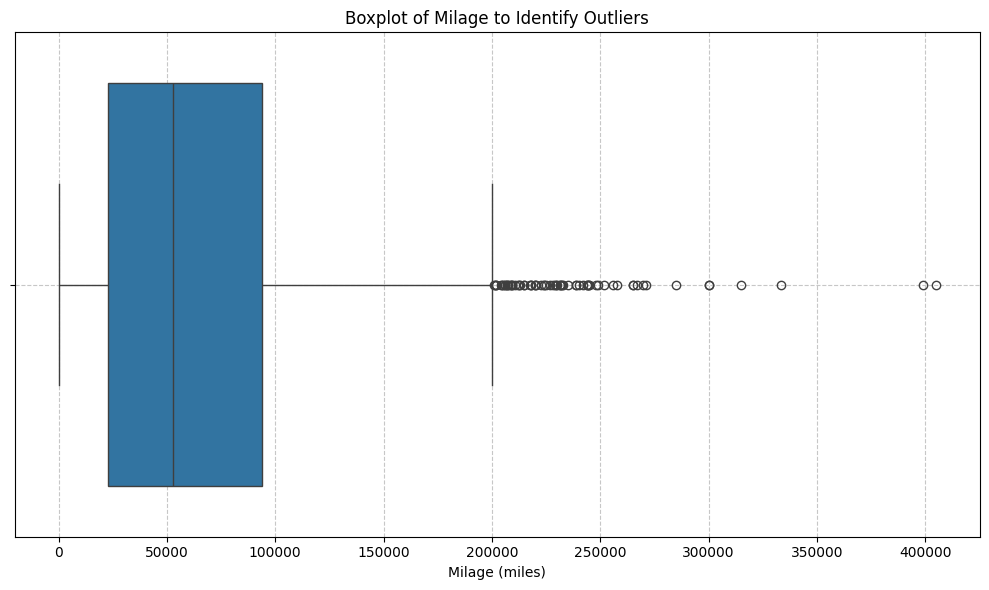

In [ ]:
# Visualize the distribution of 'milage' using a boxplot to identify outliers.
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['milage'])
plt.title('Boxplot of Milage to Identify Outliers')
plt.xlabel('Milage (miles)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

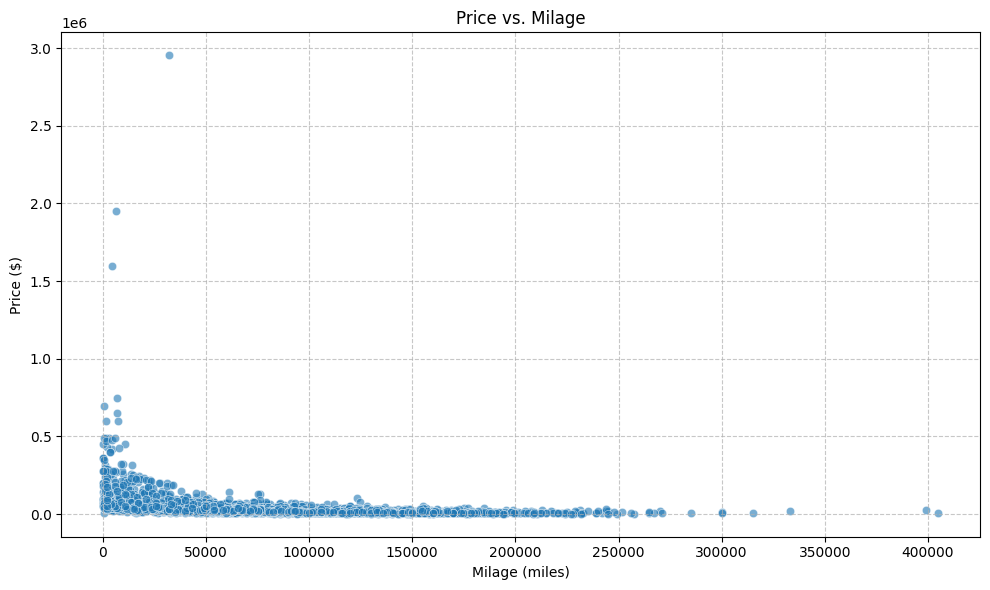

In [ ]:
# Create a scatter plot to visualize the relationship between 'milage' and 'price'.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='milage', y='price', alpha=0.6)
plt.title('Price vs. Milage')
plt.xlabel('Milage (miles)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

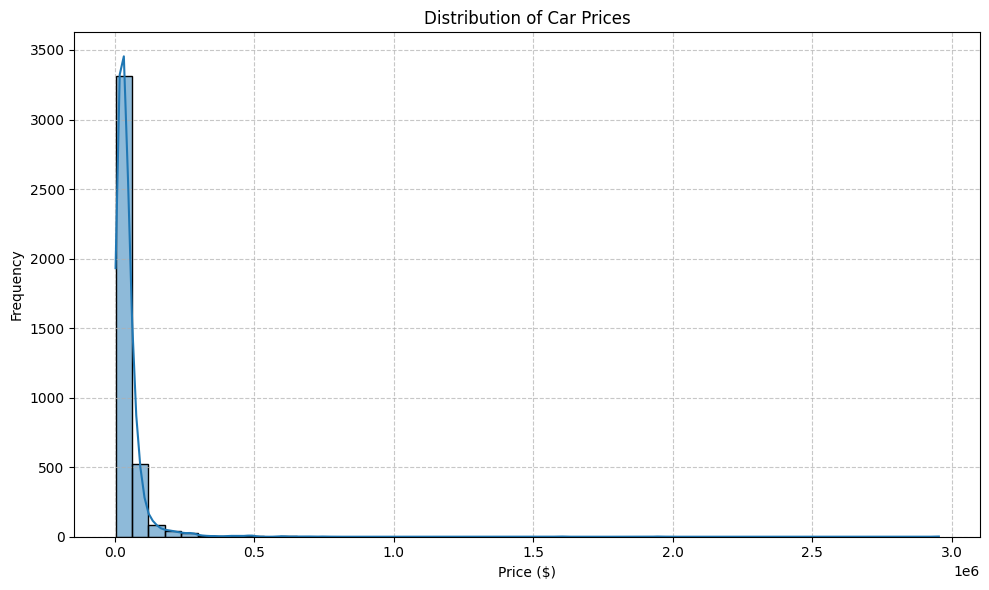

In [ ]:
# Plot a histogram to show the distribution of car 'price'.
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

***Bivariate Analysis***

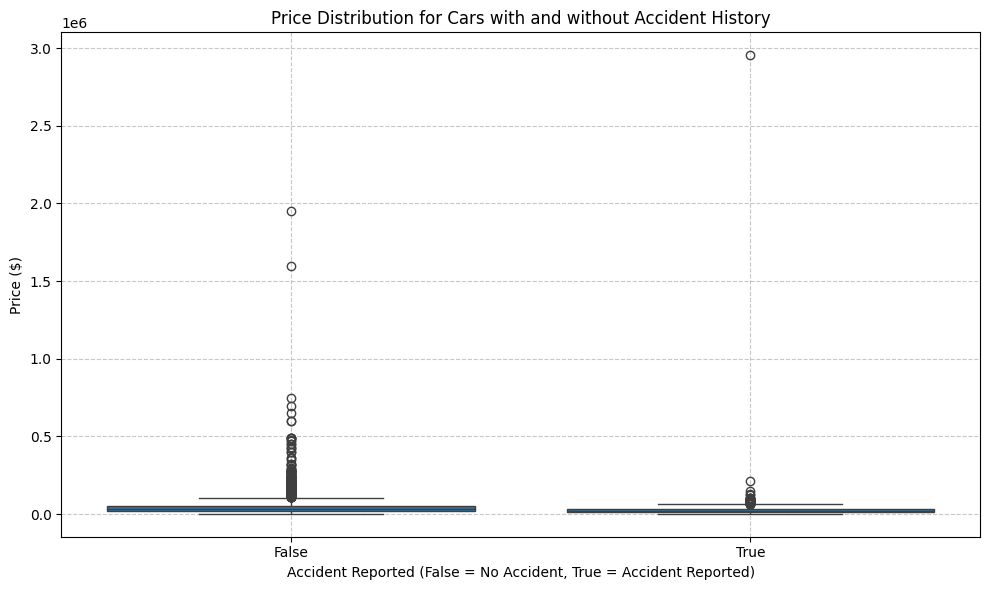

In [ ]:
# Compare the price distribution for cars with and without accident history using a boxplot.
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='accident_reported', y='price')
plt.title('Price Distribution for Cars with and without Accident History')
plt.xlabel('Accident Reported (False = No Accident, True = Accident Reported)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

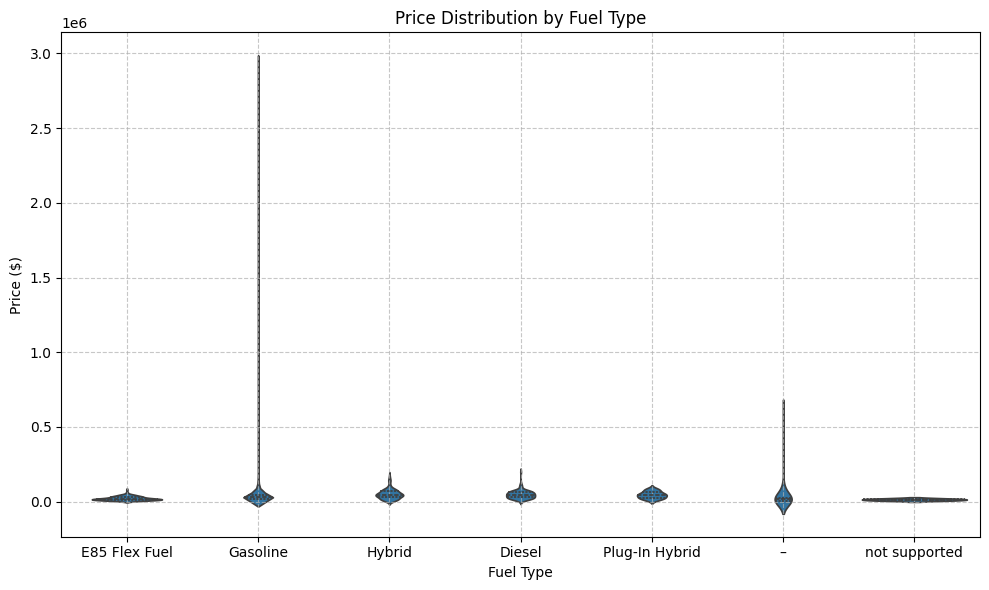

In [ ]:
# Visualize the price distribution across different 'fuel_type' categories using a violin plot.
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x='fuel_type', y='price', inner='quartile')
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Meaningful Insights from EDA
Based on the Exploratory Data Analysis we performed, here are three meaningful insights:

Inverse Relationship between Mileage and Price: The scatter plot titled 'Price vs. Milage' clearly demonstrates a negative correlation. As the mileage of a car increases, its price generally tends to decrease. This is an expected and strong trend, as higher mileage typically indicates more wear and tear, leading to depreciation.

Impact of Accident History on Price: The box plot comparing 'Price Distribution for Cars with and without Accident History' reveals a significant difference. Cars with a reported accident history (accident_reported = True) tend to have a lower median price and often a narrower, lower overall price distribution compared to vehicles without any reported accidents. This suggests that an accident history substantially reduces a car's market value.

Price Variation by Fuel Type: The violin plot titled 'Price Distribution by Fuel Type' shows that the distribution of car prices varies distinctly across different fuel types. Some fuel types (e.g., Diesel, Electric, or Hybrid, depending on specific market values) might command higher median prices or display a wider range of prices, reflecting differences in cost, efficiency, demand, or performance associated with these fuel types.

### Data Preparation for Modeling

In [ ]:
# Import necessary modules for model preparation.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np # Import numpy for log transformation

# Define categorical and numerical features more selectively
categorical_features = ['brand', 'fuel_type', 'transmission']
numerical_features = ['model_year', 'milage', 'horsepower', 'car_age', 'accident_reported']

print(f"Categorical Features: {list(categorical_features)}")
print(f"Numerical Features: {list(numerical_features)}")

Categorical Features: ['brand', 'fuel_type', 'transmission']
Numerical Features: ['model_year', 'milage', 'horsepower', 'car_age', 'accident_reported']


### Model Training and Evaluation

In [ ]:
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np # Ensure numpy is imported for expm1
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Redefine the preprocessor with remainder='drop' to handle unselected columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop' # Change from 'passthrough' to 'drop'
)

# Create the full pipeline: preprocessing + model training
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42, n_estimators=100)) # Changed to RandomForestRegressor
    ]
)

# Train the model
print("Training the Random Forest Regressor model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set (these are log-transformed)
y_pred_log = model_pipeline.predict(X_test)

# Inverse transform predictions and true values back to original scale for evaluation
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evaluate the model on the original price scale
r2 = r2_score(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)

print(f"\nModel Evaluation (on original price scale):")
print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Training the Random Forest Regressor model...
Model training complete.

Model Evaluation (on original price scale):
R-squared (R2): 0.1332
Mean Absolute Error (MAE): 17503.25
Mean Squared Error (MSE): 17716062901.98
Root Mean Squared Error (RMSE): 133101.70


In [ ]:
# Create a new binary feature 'has_clean_title'
data['has_clean_title'] = (data['clean_title'] == 'Clean').astype(int)

# Display the value counts for the new feature
print(data['has_clean_title'].value_counts(dropna=False))

# Add 'has_clean_title' to numerical features for the model
# Check if 'has_clean_title' is already in numerical_features to avoid duplicates
if 'has_clean_title' not in numerical_features:
    numerical_features.append('has_clean_title')

print(f"\nUpdated Numerical Features: {numerical_features}")

In [ ]:
# Check the unique values and their counts for the 'clean_title' column
print("Unique values in 'clean_title':")
print(data['clean_title'].unique())
print("\nValue counts for 'clean_title':")
print(data['clean_title'].value_counts(dropna=False))


Unique values in 'clean_title':
['Yes' nan]

Value counts for 'clean_title':
clean_title
Yes    3413
NaN     596
Name: count, dtype: int64


In [29]:
# Create a ColumnTransformer to apply OneHotEncoder to categorical features.
# Split the dataset into training and testing sets for model evaluation.
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y) AFTER all feature engineering
X = data.drop('price', axis=1)
y = np.log1p(data['price']) # Apply log1p transformation to the target variable

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features) # Add StandardScaler for numerical features
    ],
    remainder='drop' # Change to drop to ensure only selected features are passed to the model
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3207, 15)
X_test shape: (802, 15)
y_train shape: (3207,)
y_test shape: (802,)


The prediction model takes the cleaned data and turns it into a competitive advantage. Instead of asking, "What do we think this car is worth?" the manager can look at your Tableau dashboard and say, "Based on 4,000 recent market transactions, the algorithm says this car should be listed at exactly $18,450 to sell within 30 days."

In [30]:
data.to_csv('cleaned_used_cars_for_tableau.csv', index=False)
print("\nSuccess! Dataset exported to 'cleaned_used_cars_for_tableau.csv'")


Success! Dataset exported to 'cleaned_used_cars_for_tableau.csv'
